# Stage 1 — Safety RD Analysis

This notebook analyses the Risk Difference (RD) results from the safety pipeline.

**Condition contrast**: safe refusal vs unsafe compliance responses on BeaverTails prompts.

- **Positive RD** → expert more active during safe refusal behaviour
- **Negative RD** → expert more active during harmful compliance behaviour (primary targets for Stage 2 deactivation)

Two RD variants are analysed:
- **Frequency-based RD**: based on how often each expert is selected (top-6)
- **Logit-based RD**: based on the mean raw gate logit score per expert

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
import pandas as pd

sys.path.insert(0, os.path.join('..', 'src'))
from rd_utils import load_rd

import seaborn as sns
sns.set_theme(style='whitegrid', font='serif')
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.dpi': 150
})

RD_FREQ_PATH  = '/scratch/sc23jc3/results/rd_safety.json'
RD_LOGIT_PATH = '/scratch/sc23jc3/results/rd_safety_logits.json'
OUT_DIR = 'figures'
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
rd_freq  = load_rd(RD_FREQ_PATH)
rd_logit = load_rd(RD_LOGIT_PATH)

layers_sorted = sorted(rd_freq.keys(), key=lambda x: int(x.split('.')[2]))
layer_indices = [int(l.split('.')[2]) for l in layers_sorted]
print(f'Layers: {len(layers_sorted)},  Experts per layer: {len(next(iter(rd_freq.values())))}')

Layers: 26,  Experts per layer: 64


## 1. RD Distribution — Is the 90th Percentile Threshold Principled?

Each panel shows the distribution of all 1,664 RD values. Dashed/dotted lines mark the 90th and 95th percentiles defining the butterfly scatter threshold. The statistics box shows the fraction clustering near zero (background noise) vs the discriminative tail.

In [ ]:
# Flatten all RD values across all (layer, expert) pairs
freq_flat  = np.concatenate([rd_freq[l] for l in layers_sorted])
logit_flat = np.concatenate([rd_logit[l] for l in layers_sorted])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, label, color in zip(
    axes,
    [freq_flat, logit_flat],
    ['Frequency RD', 'Logit RD'],
    ['#e74c3c', '#c0392b']
 ):
    ax.hist(vals, bins=60, alpha=0.45, color=color, density=True)
    kde_x = np.linspace(vals.min(), vals.max(), 400)
    kde = stats.gaussian_kde(vals)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)

    near_zero = np.mean(np.abs(vals) < 0.05) * 100
    p90 = np.percentile(np.abs(vals), 90)
    p95 = np.percentile(np.abs(vals), 95)

    for q, ls, lbl in [(90, '--', '90th'), (95, ':', '95th')]:
        thresh = np.percentile(np.abs(vals), q)
        ax.axvline(thresh, color='#2c3e50', linestyle=ls, alpha=0.8, linewidth=1.4,
                   label=f'|RD| {lbl} = {thresh:.4f}')
        ax.axvline(-thresh, color='#2c3e50', linestyle=ls, alpha=0.8, linewidth=1.4)

    stats_text = f'{near_zero:.0f}% near zero\n90th = {p90:.4f}\n95th = {p95:.4f}'
    ax.text(0.97, 0.03, stats_text, transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.set_xlabel('RD value')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} (N={len(vals):,})')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Safety RD Values', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 2. Top Experts by |RD| — Frequency

## 3. Top Experts by |RD| — Logit

In [7]:
def plot_butterfly(rd_by_layer, layers_sorted, label_a, label_b, title,
                   threshold_quantile=0.90, color_a='#2980b9', color_b='#c0392b',
                   filename=None):
    all_abs = np.concatenate([np.abs(rd) for rd in rd_by_layer.values()])
    threshold = np.quantile(all_abs, threshold_quantile)

    rng = np.random.default_rng(42)
    xs, ys, expert_labels, colors = [], [], [], []

    for layer in layers_sorted:
        layer_idx = int(layer.split('.')[2])
        rd = rd_by_layer[layer]
        for expert_idx in range(len(rd)):
            if abs(rd[expert_idx]) >= threshold:
                val = float(rd[expert_idx])
                xs.append(val)
                ys.append(layer_idx + rng.uniform(-0.35, 0.35))
                expert_labels.append(str(expert_idx))
                colors.append(color_a if val > 0 else color_b)

    abs_max = max(abs(v) for v in xs)
    x_pad = max(0.02, abs_max * 0.08)
    x_max = abs_max + x_pad
    layer_indices = [int(l.split('.')[2]) for l in layers_sorted]

    fig, ax = plt.subplots(figsize=(12, 9))
    for x, y, lbl, c in zip(xs, ys, expert_labels, colors):
        ax.text(x, y, lbl, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=3,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=c, edgecolor='none', alpha=0.9))

    ax.axvline(0, color='black', linewidth=1.2, zorder=1)
    ax.set_xlim(-x_max, x_max)
    ax.set_ylim(min(ys) - 0.8, max(ys) + 1.2)
    ax.set_yticks(layer_indices)
    ax.set_yticklabels(layer_indices, fontsize=8)

    y_top = max(ys) + 0.9
    ax.text(-x_max * 0.97, y_top, f'← {label_b} preferred',
            ha='left', va='bottom', fontsize=9, color='#555555', style='italic')
    ax.text(x_max * 0.97, y_top, f'{label_a} preferred →',
            ha='right', va='bottom', fontsize=9, color='#555555', style='italic')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_a, markersize=9, label=f'{label_a} preferred'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_b, markersize=9, label=f'{label_b} preferred'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    ax.set_xlabel('RD value')
    ax.set_ylabel('Layer Index')
    ax.set_title(title)
    pct = int((1 - threshold_quantile) * 100)
    ax.text(0.5, -0.06, f'Showing top {pct}% by |RD| — number = expert index',
            transform=ax.transAxes, fontsize=8, ha='center', color='grey')
    plt.tight_layout()
    if filename:
        plt.savefig(os.path.join(OUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()

## 4. Butterfly Scatter — Significant RD Experts (Frequency)

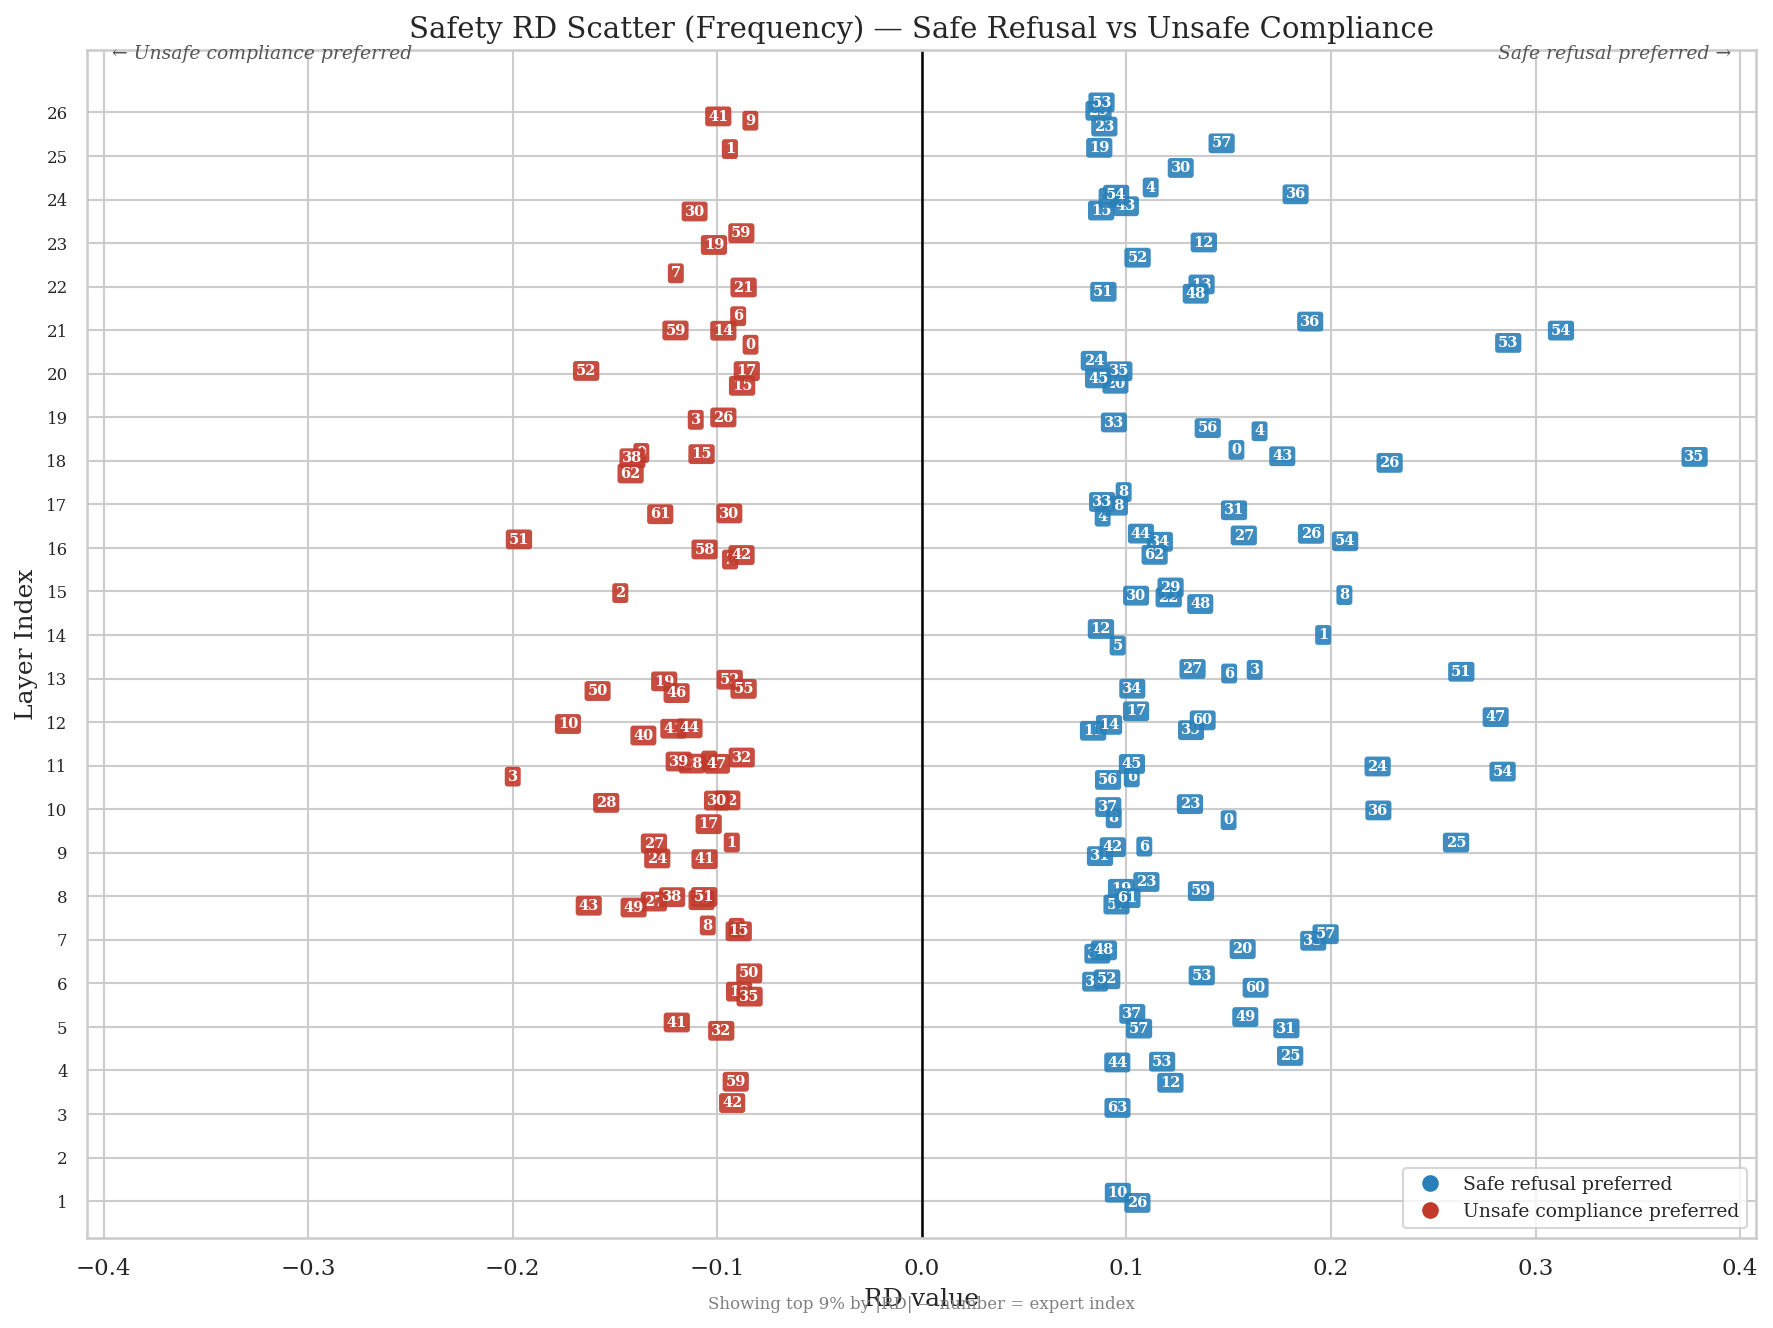

In [8]:
plot_butterfly(rd_freq, layers_sorted,
               label_a='Safe refusal', label_b='Unsafe compliance',
               title='Safety RD Scatter (Frequency) — Safe Refusal vs Unsafe Compliance',
               filename='safety_rd_butterfly_freq.png')

## 5. Butterfly Scatter — Significant RD Experts (Logit)

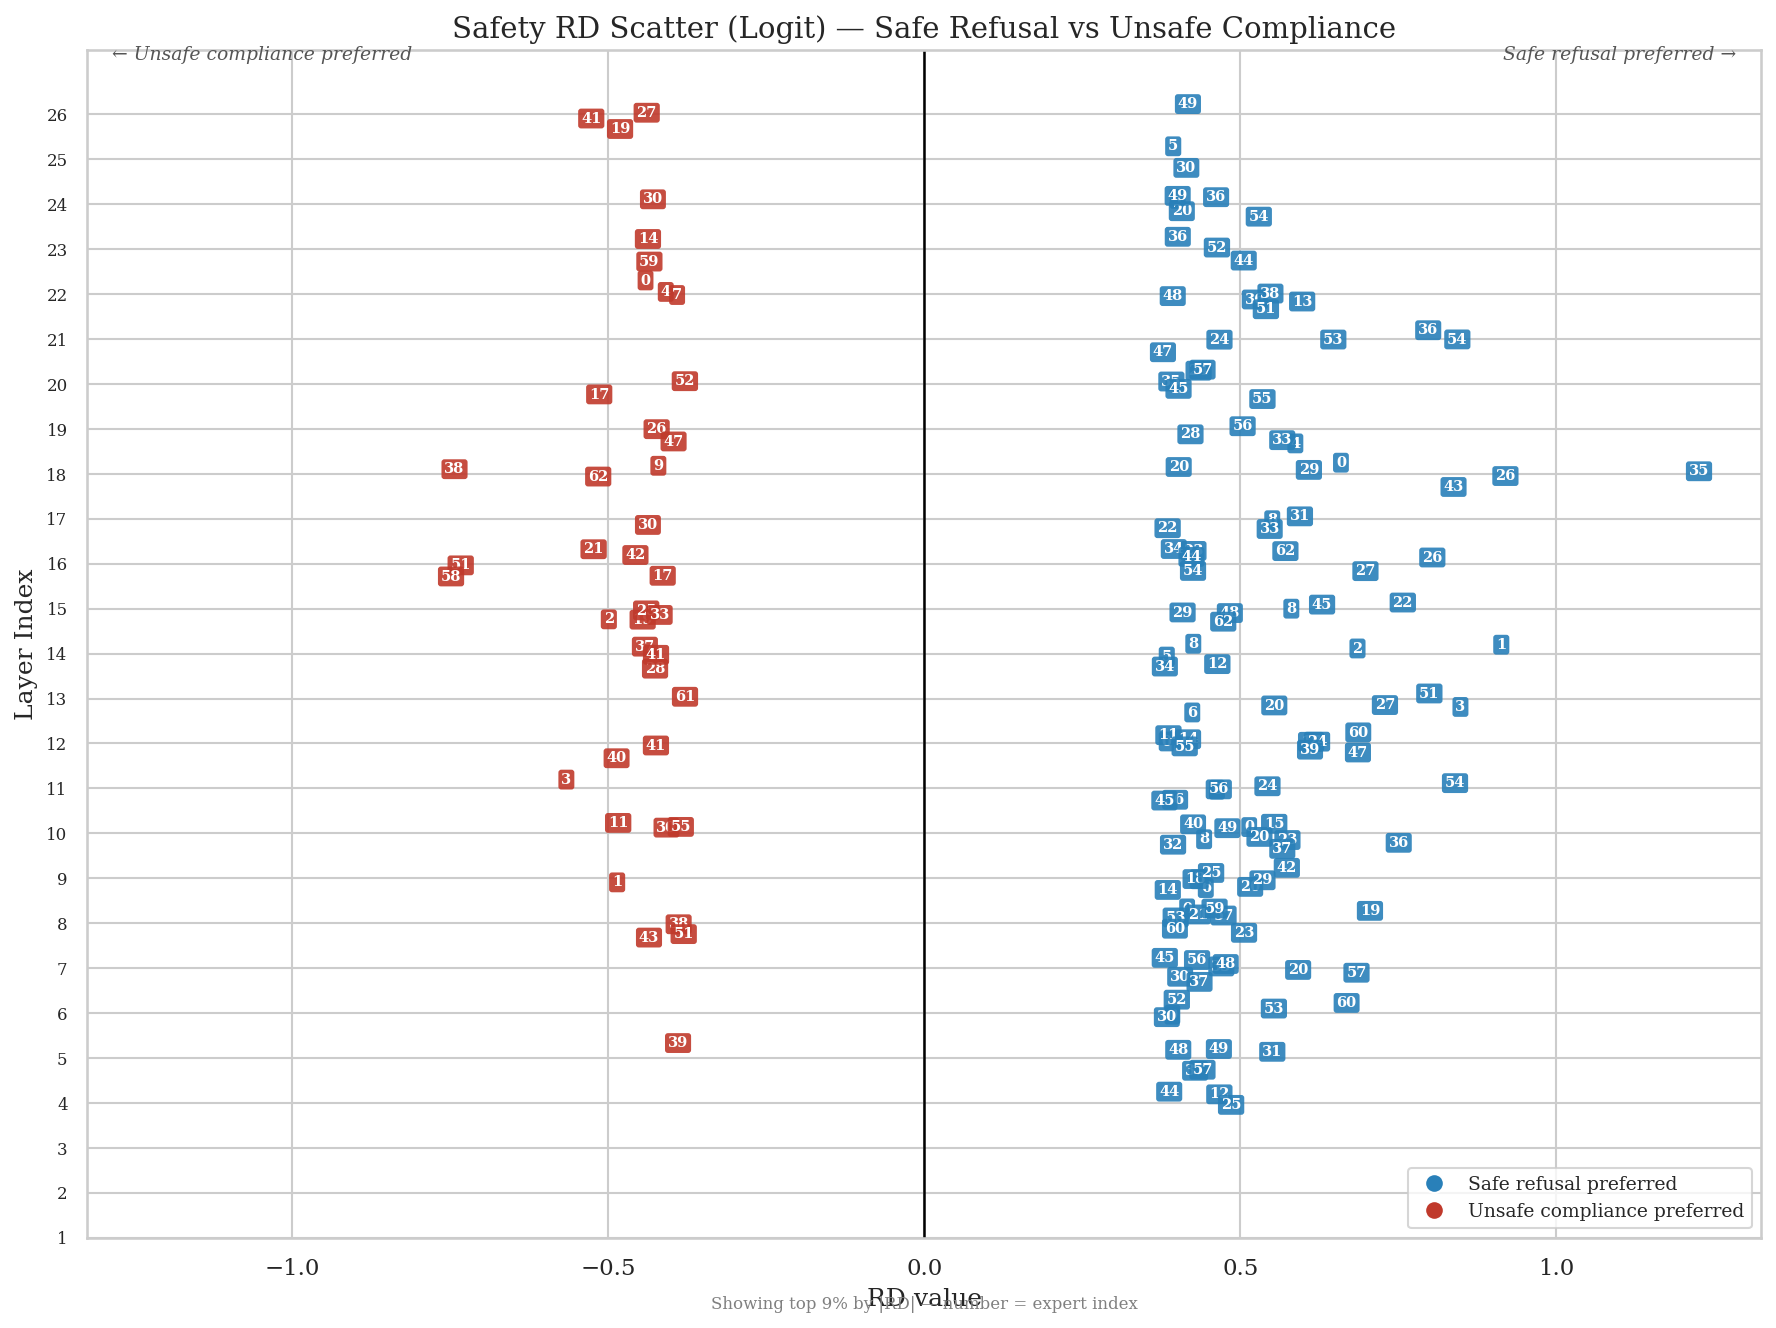

In [9]:
plot_butterfly(rd_logit, layers_sorted,
               label_a='Safe refusal', label_b='Unsafe compliance',
               title='Safety RD Scatter (Logit) — Safe Refusal vs Unsafe Compliance',
               filename='safety_rd_butterfly_logit.png')

## 6. Layer Distribution of Compliance-Preferred Experts

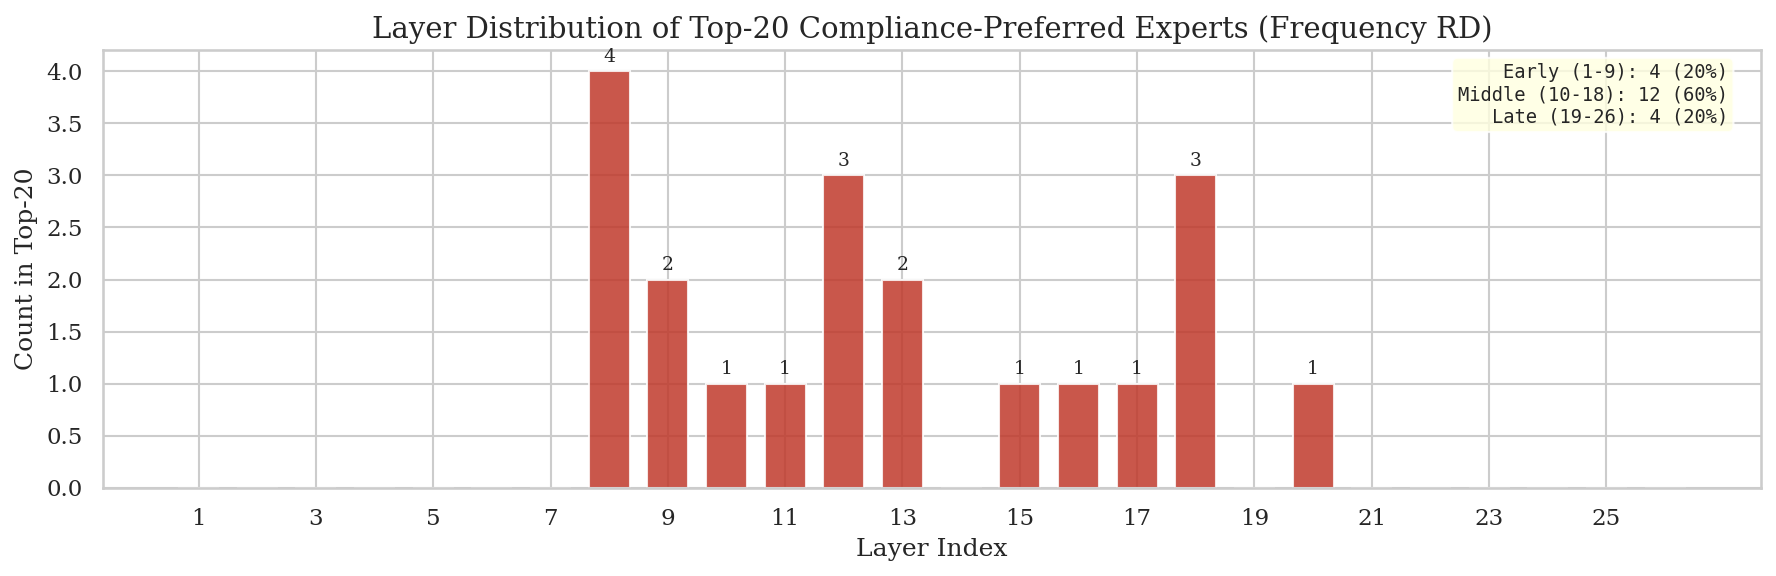

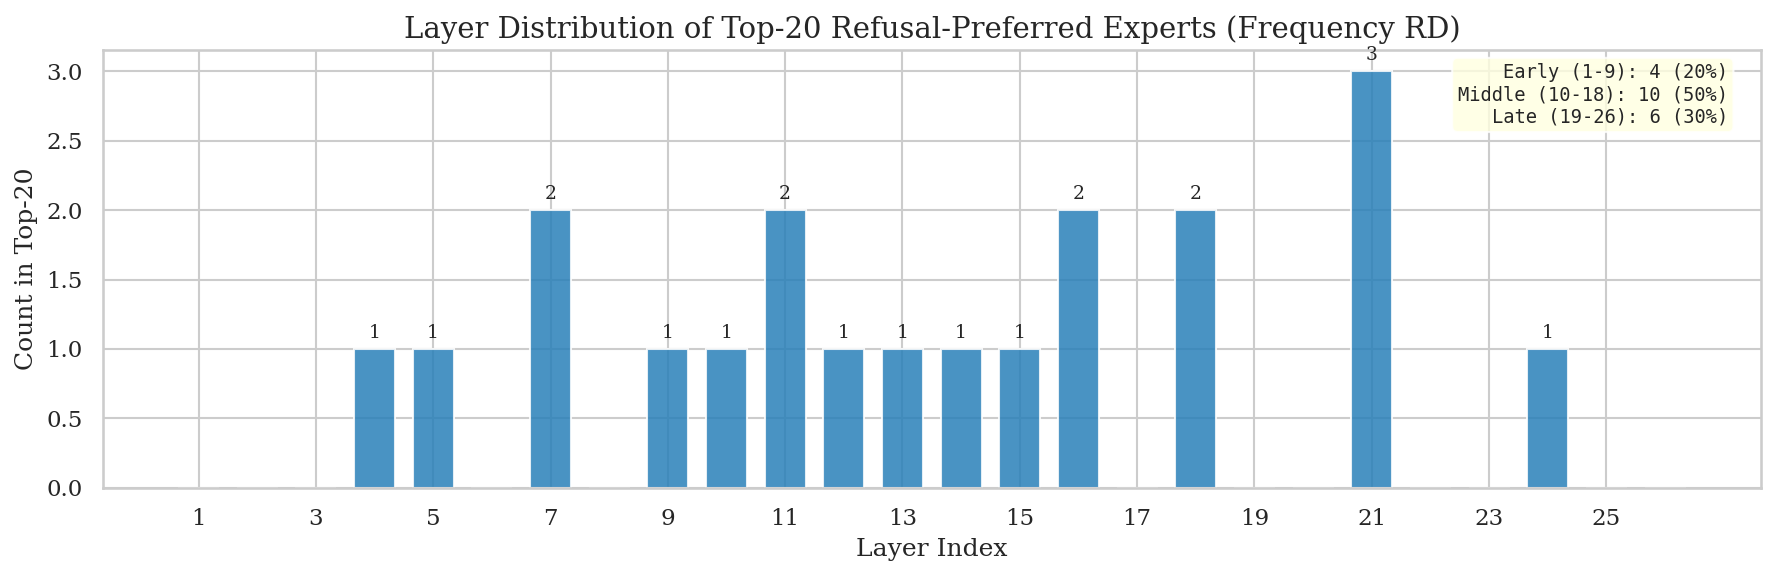

In [10]:
# Among the top-20 compliance-preferred (most negative RD) experts, which layers do they come from?
rows = []
for layer, rd in rd_freq.items():
    layer_idx = int(layer.split('.')[2])
    for expert_idx, val in enumerate(rd):
        rows.append((val, layer_idx, expert_idx))

rows.sort()  # ascending = most negative first
top_neg = rows[:20]

layer_counts = {}
for val, layer_idx, _ in top_neg:
    layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1

fig, ax = plt.subplots(figsize=(12, 4))
all_layer_idxs = [int(l.split('.')[2]) for l in layers_sorted]
counts = [layer_counts.get(li, 0) for li in all_layer_idxs]
bars = ax.bar(all_layer_idxs, counts, color='#c0392b', alpha=0.85, width=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Count in Top-20')
ax.set_title('Layer Distribution of Top-20 Compliance-Preferred Experts (Frequency RD)')
ax.set_xticks(all_layer_idxs[::2])

for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(count), ha='center', va='bottom', fontsize=9)

early = sum(c for li, c in layer_counts.items() if li <= 8)
middle = sum(c for li, c in layer_counts.items() if 9 <= li <= 17)
late = sum(c for li, c in layer_counts.items() if li >= 18)
total = early + middle + late

breakdown_text = f'Early (1-9): {early} ({early/total*100:.0f}%)\nMiddle (10-18): {middle} ({middle/total*100:.0f}%)\nLate (19-26): {late} ({late/total*100:.0f}%)'
ax.text(0.98, 0.97, breakdown_text, transform=ax.transAxes,
        fontsize=9, ha='right', va='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'safety_neg_expert_layers.png'), dpi=300, bbox_inches='tight')
plt.show()

# Also plot refusal-preferred experts (most positive RD)
rows_pos = []
for layer, rd in rd_freq.items():
    layer_idx = int(layer.split('.')[2])
    for expert_idx, val in enumerate(rd):
        rows_pos.append((val, layer_idx, expert_idx))

rows_pos.sort(reverse=True)  # descending = most positive first
top_pos = rows_pos[:20]

layer_counts_pos = {}
for val, layer_idx, _ in top_pos:
    layer_counts_pos[layer_idx] = layer_counts_pos.get(layer_idx, 0) + 1

fig, ax = plt.subplots(figsize=(12, 4))
counts_pos = [layer_counts_pos.get(li, 0) for li in all_layer_idxs]
bars_pos = ax.bar(all_layer_idxs, counts_pos, color='#2980b9', alpha=0.85, width=0.7)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Count in Top-20')
ax.set_title('Layer Distribution of Top-20 Refusal-Preferred Experts (Frequency RD)')
ax.set_xticks(all_layer_idxs[::2])

for bar, count in zip(bars_pos, counts_pos):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(count), ha='center', va='bottom', fontsize=9)

early_pos = sum(c for li, c in layer_counts_pos.items() if li <= 8)
middle_pos = sum(c for li, c in layer_counts_pos.items() if 9 <= li <= 17)
late_pos = sum(c for li, c in layer_counts_pos.items() if li >= 18)
total_pos = early_pos + middle_pos + late_pos

breakdown_text_pos = f'Early (1-9): {early_pos} ({early_pos/total_pos*100:.0f}%)\nMiddle (10-18): {middle_pos} ({middle_pos/total_pos*100:.0f}%)\nLate (19-26): {late_pos} ({late_pos/total_pos*100:.0f}%)'
ax.text(0.98, 0.97, breakdown_text_pos, transform=ax.transAxes,
        fontsize=9, ha='right', va='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'safety_pos_expert_layers.png'), dpi=300, bbox_inches='tight')
plt.show()